# 4. Modelado

La fase 3 dejó `coffee_balance_long.parquet` con el balance histórico. Esta fase responde la pregunta que sigue:
**¿qué países productores van a necesitar importar café en los próximos tres años, y con qué grado de certeza?**

El modelo no es el entregable: es el insumo. El entregable son dos cifras por país y año cafetero:

- **Probabilidad de déficit:** en qué porcentaje de los escenarios simulados el consumo supera a la producción.
- **Necesidad esperada de importación:** cuántos sacos, en promedio, tendría que comprar afuera ese mercado.

La segunda combina tamaño y certeza en una sola cifra en sacos, sin pesos arbitrarios: un déficit grande pero improbable
y uno pequeño pero seguro quedan comparados en la misma unidad.

## 4.0 Configuración

In [3]:
#%pip install statsmodels

In [1]:
from pathlib import Path
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.holtwinters import ExponentialSmoothing

warnings.filterwarnings("ignore")

DATA_DIR = Path(
    r"C:\Users\david\Desktop\Personal\github_master\prueba-nttdata\data"
)

HORIZONTE = 3
MIN_ENTRENAMIENTO = 6
MIN_ANIOS_SERIE = 10
MIN_ERRORES_POR_HORIZONTE = 5
N_SIMULACIONES = 1_000
SEMILLA = 42
MODELOS = ["ingenuo", "drift", "ets", "arima"]
VARIABLES = ["consumo_sacos", "produccion_sacos"]

rng = np.random.default_rng(SEMILLA)
pd.set_option("display.width", 220)
pd.set_option("display.max_columns", 40)
plt.rcParams.update({"figure.dpi": 100, "axes.grid": True, "grid.alpha": 0.3})

balance = pd.read_parquet(DATA_DIR / "coffee_balance_long.parquet")
ULTIMO_ANIO = int(balance["anio_inicio"].max())
FUTURO = [ULTIMO_ANIO + i for i in range(1, HORIZONTE + 1)]
CROP_FUTURO = {a: f"{a}/{str(a + 1)[2:]}" for a in FUTURO}

paises = (balance[~balance["segmento"].str.startswith("excluido")]
          .groupby("country")["segmento"].first())
print(f"países a proyectar: {len(paises)} | horizonte: {CROP_FUTURO[FUTURO[0]]} → {CROP_FUTURO[FUTURO[-1]]}")
print(paises.value_counts().to_string())

países a proyectar: 45 | horizonte: 2020/21 → 2022/23
segmento
consumo plano: proyección constante    27
modelable                              18


## 4.1 Diseño del modelado

**Qué se modela.** Consumo y producción por separado, no el ratio. La producción es unas tres veces más volátil que el consumo,
así que un modelo sobre el ratio heredaría ese ruido y no permitiría ver de dónde viene la incertidumbre.

**En logaritmo.** Ambas series son positivas y crecen de forma multiplicativa. El logaritmo estabiliza la varianza y evita
que una simulación arroje consumos negativos.

**Qué series entran.** Las de países no excluidos en la fase 3. En los países con consumo plano, el consumo se proyecta con
el modelo ingenuo por construcción, y se marcan como de menor confiabilidad; su producción sí se modela normalmente.
La producción de Filipinas usa solo el tramo posterior a su quiebre de serie, como decidió la fase 3.

In [8]:
def obtener_serie(country, variable):
    filas = balance[balance["country"] == country]
    if variable == "produccion_sacos":
        filas = filas[filas["usar_para_modelo_produccion"]]
    serie = filas.set_index("anio_inicio")[variable].dropna()
    return np.log(serie)

SERIES = {(c, v): obtener_serie(c, v) for c in paises.index for v in VARIABLES}
SERIES = {k: s for k, s in SERIES.items() if len(s) >= MIN_ANIOS_SERIE}

print(f"series con historia suficiente: {len(SERIES)}")
print(pd.Series({f"{v}": sum(1 for (c, vv) in SERIES if vv == v) for v in VARIABLES}).to_string())

series con historia suficiente: 90
consumo_sacos       45
produccion_sacos    45


## 4.2 Modelos candidatos

Con 30 observaciones anuales por país no caben modelos complejos: solo órdenes bajos son estimables y una búsqueda automática
de hiperparámetros sobreajustaría. Los cuatro candidatos cubren el rango razonable:

- **Ingenuo:** repite el último valor. Es la línea base obligatoria; cualquier modelo que no la supere no se justifica.
- **Drift:** extiende la pendiente media de toda la serie. Muy robusto con series cortas.
- **ETS amortiguado:** suavizamiento exponencial con tendencia que se va apagando, para no extrapolar indefinidamente.
- **ARIMA(1,1,0) con deriva:** coherente con el resultado de la fase 2, donde la mayoría de las series resultaron estacionarias
  en primera diferencia.

ETS y ARIMA caen al drift si la estimación no converge, para que una serie difícil no rompa el proceso.

In [9]:
def pronosticar(serie, modelo, h=HORIZONTE):
    x = serie.values
    if modelo == "ingenuo":
        return np.repeat(x[-1], h)
    if modelo == "drift":
        pendiente = (x[-1] - x[0]) / (len(x) - 1)
        return x[-1] + pendiente * np.arange(1, h + 1)
    if modelo == "ets":
        try:
            ajuste = ExponentialSmoothing(x, trend="add", damped_trend=True,
                                          initialization_method="estimated").fit()
            return np.asarray(ajuste.forecast(h))
        except Exception:
            return pronosticar(serie, "drift", h)
    if modelo == "arima":
        try:
            return np.asarray(ARIMA(x, order=(1, 1, 0), trend="t").fit().forecast(h))
        except Exception:
            return pronosticar(serie, "drift", h)
    raise ValueError(modelo)

## 4.3 Backtesting con origen móvil

La validación replica exactamente el uso real: pararse en un año, proyectar tres hacia adelante y comparar con lo que pasó.
Se repite el ejercicio moviendo el origen hacia atrás mientras el entrenamiento conserve al menos la mitad de la serie,
así que una serie completa se evalúa una docena de veces en vez de una. Eso importa doblemente: da una medida de error más estable y, sobre todo,
produce la distribución de errores que alimenta la simulación de la sección 4.5.

El error se mide con **MASE**: el error absoluto dividido por el error que cometería el modelo ingenuo de un paso dentro del
entrenamiento. Es adimensional, así que permite promediar países de tamaños muy distintos, y su lectura es directa:
por debajo de 1, el modelo aporta sobre repetir el último valor conocido.

Se guarda también el error en logaritmo de cada pronóstico, porque esos errores son los que después alimentan la simulación.

In [10]:
def backtest(serie, modelos=MODELOS, h=HORIZONTE):
    filas = []
    minimo = max(MIN_ENTRENAMIENTO, len(serie) // 2)
    for corte in range(len(serie) - h, minimo - 1, -1):
        entrena, prueba = serie.iloc[:corte], serie.iloc[corte:corte + h]
        if len(prueba) < h:
            continue
        escala = np.abs(np.diff(np.exp(entrena.values))).mean()
        escala = escala if escala > 0 else np.nan
        for modelo in modelos:
            pred = pronosticar(entrena, modelo, h)
            for i in range(h):
                filas.append({"modelo": modelo, "origen": int(entrena.index[-1]), "h": i + 1,
                              "pred_log": pred[i], "real_log": prueba.values[i],
                              "error_log": prueba.values[i] - pred[i],
                              "mase": abs(np.exp(prueba.values[i]) - np.exp(pred[i])) / escala})
    return pd.DataFrame(filas)

resultados = []
for (pais, variable), serie in SERIES.items():
    bt = backtest(serie)
    bt.insert(0, "country", pais)
    bt.insert(1, "variable", variable)
    resultados.append(bt)
backtesting = pd.concat(resultados, ignore_index=True)

cortes_por_serie = backtesting.groupby(["country", "variable"])["origen"].nunique()
print(f"pronósticos evaluados: {len(backtesting):,}")
print(f"orígenes por serie: mediana {cortes_por_serie.median():.0f}, mínimo {cortes_por_serie.min()}")
print(f"series sin MASE definido (consumo constante en el entrenamiento): "
      f"{backtesting.groupby(['country', 'variable'])['mase'].apply(lambda s: s.isna().all()).sum()}")
backtesting.pivot_table(index="modelo", columns="variable", values="mase", aggfunc="mean").round(3)

pronósticos evaluados: 13,908
orígenes por serie: mediana 13, mínimo 2
series sin MASE definido (consumo constante en el entrenamiento): 1


variable,consumo_sacos,produccion_sacos
modelo,,
arima,2.017,0.856
drift,2.059,0.919
ets,1.772,0.836
ingenuo,1.631,0.842


In [11]:
por_horizonte = backtesting.pivot_table(index="h", columns="modelo", values="mase", aggfunc="mean").round(3)
print("MASE promedio por horizonte:")
print(por_horizonte.to_string())

MASE promedio por horizonte:
modelo  arima  drift    ets  ingenuo
h                                   
1       0.929  0.959  0.927    0.832
2       1.412  1.470  1.289    1.230
3       1.946  2.016  1.676    1.633


## 4.4 Selección del modelo por serie

Ningún modelo gana en todas partes, así que la elección se hace **serie por serie**, con el MASE promedio de todos sus orígenes.
Es el mismo criterio para las dos variables y no requiere intervención manual.

En las series de consumo constante el MASE no está definido (su denominador es cero porque el valor nunca cambia);
esas series se quedan con el modelo ingenuo, que es justamente lo que decidió la fase 3.

La comparación contra el ingenuo es la que valida la hipótesis H4 del entendimiento del negocio.

In [12]:
mase_medio = backtesting.groupby(["country", "variable", "modelo"])["mase"].mean().unstack()
elegidos = mase_medio.apply(lambda fila: fila.idxmin() if fila.notna().any() else "ingenuo", axis=1).rename("modelo")

forzar_ingenuo = [(c, "consumo_sacos") for c in paises.index[paises.str.startswith("consumo plano")]]
elegidos.loc[[k for k in forzar_ingenuo if k in elegidos.index]] = "ingenuo"

comparacion = pd.DataFrame({
    "mase_elegido": [mase_medio.loc[k, elegidos[k]] for k in elegidos.index],
    "mase_ingenuo": mase_medio["ingenuo"],
}, index=elegidos.index).assign(mejora=lambda d: 1 - d["mase_elegido"] / d["mase_ingenuo"])

print(elegidos.groupby([elegidos.index.get_level_values("variable"), elegidos]).size().unstack(fill_value=0).to_string())
print(f"\nseries donde el modelo elegido supera al ingenuo: "
      f"{(comparacion['mase_elegido'] < comparacion['mase_ingenuo']).sum()} de {len(comparacion)}")
print(f"series con MASE < 1: {(comparacion['mase_elegido'] < 1).sum()} de {len(comparacion)}")
print(f"mejora media sobre el ingenuo: {comparacion['mejora'].mean():.1%}")

modelo            arima  drift  ets  ingenuo
variable                                    
consumo_sacos         1      5    9       30
produccion_sacos     10      5   17       13

series donde el modelo elegido supera al ingenuo: 47 de 90
series con MASE < 1: 62 de 90
mejora media sobre el ingenuo: 13.3%


**Lectura de la selección.** El modelo elegido supera al ingenuo en 47 de las 90 series y la mejora media es del 13 %,
así que **H4 se confirma solo a medias**: no hay un modelo que gane siempre. En consumo, el ingenuo se lleva 30 de 45 series,
porque muchas son escalonadas y repetir el último valor es literalmente lo que hace la fuente. En producción, en cambio,
ETS y ARIMA ganan en 27 de 45: ahí sí hay estructura que aprovechar.

El MASE promedio crece con el horizonte (0,83 a un año, 1,63 a tres para el ingenuo): a tres años, el error supera al de
repetir el último valor dentro del entrenamiento. Es el recordatorio de por qué la proyección se entrega con probabilidad
y no como un número único.

## 4.5 Proyección con simulación

Un valor puntual no sirve para decidir: el área comercial necesita saber qué tan probable es el déficit, no solo su valor central.

En vez de suponer que los errores se distribuyen normalmente, se remuestrean **los errores reales del backtesting** de esa misma
serie y ese mismo horizonte (bootstrap). Así el rango de incertidumbre refleja lo que el modelo efectivamente falló en el pasado,
incluyendo la asimetría y los años malos.

Cada simulación genera una trayectoria de consumo y una de producción; el balance se calcula escenario por escenario. Después:

- **Probabilidad de déficit** = fracción de escenarios con balance negativo.
- **Necesidad esperada de importación** = promedio de `max(0, consumo − producción)` sobre todos los escenarios.

Consumo y producción se simulan de forma independiente. Es una simplificación: un choque económico puede mover ambos a la vez.

In [13]:
def simular(pais, variable, errores_hasta=None, n=N_SIMULACIONES, generador=rng, modelo_forzado=None):
    serie = SERIES[(pais, variable)]
    modelo = modelo_forzado or elegidos[(pais, variable)]
    pred = pronosticar(serie, modelo)
    errores = backtesting[(backtesting["country"] == pais) & (backtesting["variable"] == variable)
                          & (backtesting["modelo"] == modelo)]
    if errores_hasta is not None:
        errores = errores[errores["origen"] < errores_hasta]
    trayectorias = np.empty((n, HORIZONTE))
    for i in range(HORIZONTE):
        muestra = errores.loc[errores["h"] == i + 1, "error_log"].values
        if muestra.size < MIN_ERRORES_POR_HORIZONTE:
            muestra = errores["error_log"].values
        ruido = generador.choice(muestra, size=n, replace=True) if muestra.size else np.zeros(n)
        trayectorias[:, i] = np.exp(pred[i] + ruido)
    return trayectorias

def indicadores(pais, errores_hasta=None, generador=rng, modelo_forzado=None):
    consumo = simular(pais, "consumo_sacos", errores_hasta, generador=generador, modelo_forzado=modelo_forzado)
    produccion = simular(pais, "produccion_sacos", errores_hasta, generador=generador, modelo_forzado=modelo_forzado)
    faltante = np.maximum(0, consumo - produccion)
    return pd.DataFrame({
        "country": pais,
        "anio_inicio": FUTURO,
        "prob_deficit": (consumo > produccion).mean(axis=0),
        "necesidad_esperada_sacos": faltante.mean(axis=0),
        "balance_mediano_sacos": np.median(produccion - consumo, axis=0),
        "consumo_mediano_sacos": np.median(consumo, axis=0),
        "produccion_mediana_sacos": np.median(produccion, axis=0),
    })

modelables = [c for c in paises.index
              if all((c, v) in elegidos.index for v in VARIABLES)]
proyeccion = pd.concat([indicadores(c) for c in modelables], ignore_index=True)
proyeccion["crop_year"] = proyeccion["anio_inicio"].map(CROP_FUTURO)

print(f"países proyectados: {proyeccion['country'].nunique()} | escenarios por país y año: {N_SIMULACIONES:,}")
proyeccion.head(3).round(2)

países proyectados: 45 | escenarios por país y año: 1,000


,country,anio_inicio,prob_deficit,necesidad_esperada_sacos,balance_mediano_sacos,consumo_mediano_sacos,produccion_mediana_sacos,crop_year
0,Angola,2020,0.12,1254.28,25233.20,30000.0,55233.20,2020/21
1,Angola,2021,0.16,1916.85,25557.03,30000.0,58979.12,2021/22
2,Angola,2022,0.16,1890.92,23617.56,30000.0,59950.54,2022/23


## 4.6 Ranking de mercados

La tabla que recibe el área comercial. Se ordena por la necesidad esperada de importación del último año proyectado,
que ya incorpora tamaño y certeza.

La columna de confiabilidad advierte cuándo la proyección del consumo viene de una serie plana: ahí el modelo repite el último
valor por construcción y el intervalo es artificialmente angosto, así que la probabilidad debe leerse como optimista.

In [14]:
ultimo_anio = proyeccion[proyeccion["anio_inicio"] == FUTURO[-1]].set_index("country")
tipo = balance.groupby("country")["coffee_type"].first()

ranking = (ultimo_anio[["crop_year", "prob_deficit", "necesidad_esperada_sacos", "balance_mediano_sacos"]]
           .join(tipo).join(paises.rename("segmento"))
           .assign(
               modelo_consumo=[elegidos[(c, "consumo_sacos")] for c in ultimo_anio.index],
               modelo_produccion=[elegidos[(c, "produccion_sacos")] for c in ultimo_anio.index],
               anios_produccion=[len(SERIES[(c, "produccion_sacos")]) for c in ultimo_anio.index],
               confiabilidad=lambda d: np.select(
                   [d["segmento"].str.startswith("consumo plano"), d["anios_produccion"] < 20],
                   ["baja: consumo con serie plana", "baja: producción con serie corta"], "normal"))
           .sort_values("necesidad_esperada_sacos", ascending=False))

ranking.head(10).round(2)

,crop_year,prob_deficit,necesidad_esperada_sacos,balance_mediano_sacos,coffee_type,segmento,modelo_consumo,modelo_produccion,anios_produccion,confiabilidad
country,,,,,,,,,,
Philippines,2022/23,1.00,4088041.90,-3753608.78,Robusta/Arabica,modelable,drift,ingenuo,10,baja: producción con serie corta
Thailand,2022/23,1.00,1270966.53,-1101385.08,Robusta/Arabica,modelable,drift,ets,30,normal
Venezuela,2022/23,0.79,173014.54,-188286.83,Arabica,modelable,ets,ingenuo,30,normal
Cuba,2022/23,1.00,82581.98,-86944.70,Arabica,consumo plano: proyección constante,ingenuo,ingenuo,30,baja: consumo con serie plana
Madagascar,2022/23,0.63,30571.48,-24604.89,Robusta,modelable,ingenuo,arima,30,normal
Mexico,2022/23,0.02,9508.84,1276457.76,Arabica/Robusta,modelable,ets,ets,30,normal
El Salvador,2022/23,0.16,7800.39,396797.19,Arabica,modelable,ets,arima,30,normal
Central African Republic,2022/23,0.30,4690.84,21125.85,Robusta,modelable,ingenuo,arima,30,normal
Haiti,2022/23,0.64,3273.10,-2891.64,Arabica,consumo plano: proyección constante,ingenuo,drift,30,baja: consumo con serie plana


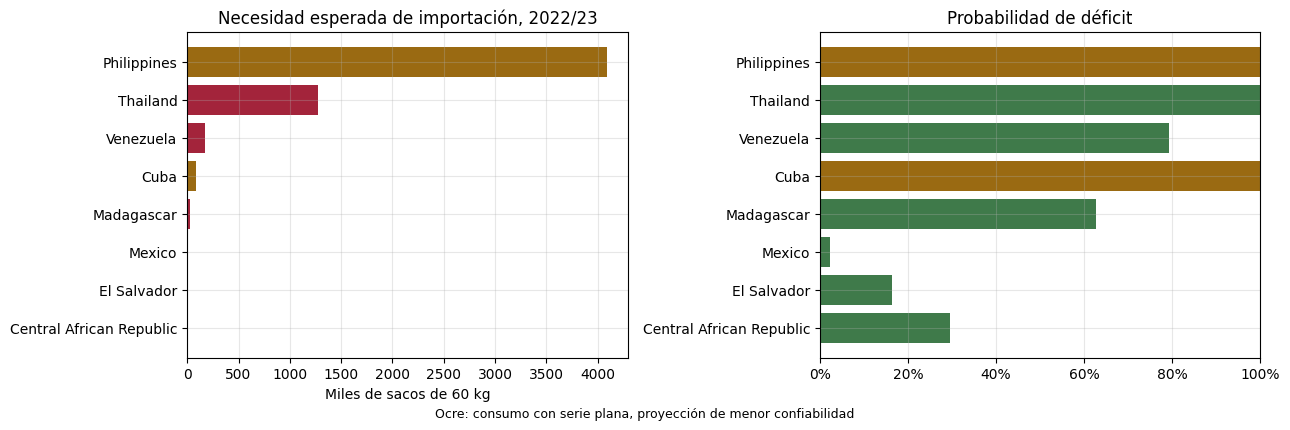

In [15]:
top = ranking.head(8).iloc[::-1]
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].barh(top.index, top["necesidad_esperada_sacos"] / 1e3,
             color=np.where(top["confiabilidad"] == "normal", "#A3243B", "#9A6A12"))
axes[0].set_title(f"Necesidad esperada de importación, {CROP_FUTURO[FUTURO[-1]]}")
axes[0].set_xlabel("Miles de sacos de 60 kg")
axes[1].barh(top.index, top["prob_deficit"],
             color=np.where(top["confiabilidad"] == "normal", "#3F7A4A", "#9A6A12"))
axes[1].set_xlim(0, 1)
axes[1].set_title("Probabilidad de déficit")
axes[1].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.0%}"))
fig.suptitle("Ocre: consumo con serie plana, proyección de menor confiabilidad", fontsize=9, y=0.02)
plt.tight_layout()
plt.show()

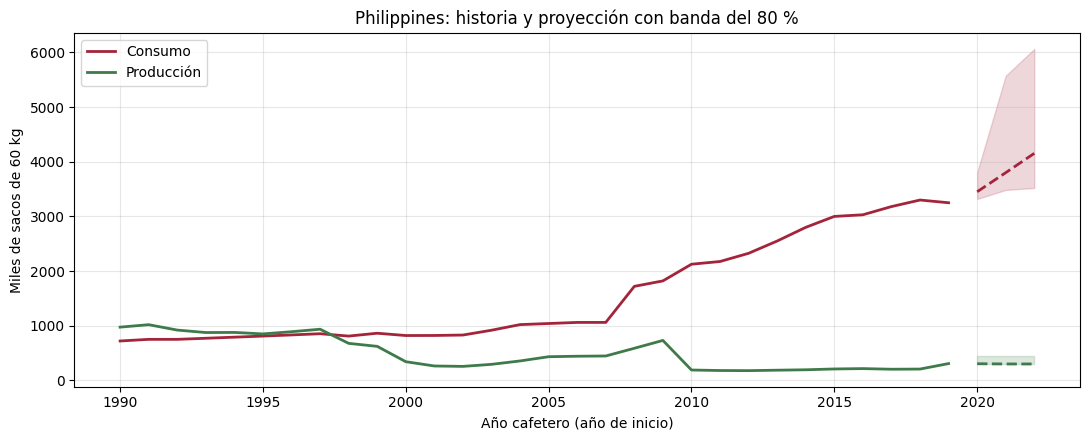

In [16]:
pais_demo = ranking.index[0]
sim_c = simular(pais_demo, "consumo_sacos")
sim_p = simular(pais_demo, "produccion_sacos")
hist = balance[balance["country"] == pais_demo].set_index("anio_inicio")

fig, ax = plt.subplots(figsize=(11, 4.5))
ax.plot(hist.index, hist["consumo_sacos"] / 1e3, color="#A3243B", linewidth=2, label="Consumo")
ax.plot(hist.index, hist["produccion_sacos"] / 1e3, color="#3F7A4A", linewidth=2, label="Producción")
for datos, color in [(sim_c, "#A3243B"), (sim_p, "#3F7A4A")]:
    ax.plot(FUTURO, np.median(datos, axis=0) / 1e3, color=color, linestyle="--", linewidth=2)
    ax.fill_between(FUTURO, np.percentile(datos, 10, axis=0) / 1e3, np.percentile(datos, 90, axis=0) / 1e3,
                    color=color, alpha=0.18)
ax.set_title(f"{pais_demo}: historia y proyección con banda del 80 %")
ax.set_xlabel("Año cafetero (año de inicio)")
ax.set_ylabel("Miles de sacos de 60 kg")
ax.legend()
plt.tight_layout()
plt.show()

## 4.7 Evaluación técnica del modelo (*assess model*)

Esta sección es la tarea de evaluación técnica que CRISP-DM ubica dentro del modelado: mide propiedades del modelo contra
datos históricos. El veredicto de negocio (si los resultados cumplen los criterios de éxito y si se despliega o no)
corresponde a la fase 5.

### ¿Se puede confiar en esas probabilidades?

Una probabilidad solo sirve si está calibrada: cuando el método dice 80 %, debería acertar cerca de 8 de cada 10 veces.
Para medirlo se repite todo el procedimiento en el pasado: pararse en un origen, proyectar tres años, calcular la probabilidad
de déficit **usando únicamente los errores de orígenes anteriores**, y comparar contra lo que realmente ocurrió.

Se resume con el **Brier score** (error cuadrático medio de la probabilidad; más bajo es mejor) y se compara contra una línea
base climatológica: predecir siempre la frecuencia histórica de déficit de ese país.

Salvedad honesta: la elección del modelo por serie se hizo con todos los orígenes, así que esta validación es ligeramente
optimista. Lo que sí es limpio es el origen de la incertidumbre, que solo usa información anterior a cada corte.

In [17]:
generador_cal = np.random.default_rng(SEMILLA + 1)
origenes = sorted(backtesting["origen"].unique())
filas = []
for origen in origenes[2:]:
    objetivo = origen + HORIZONTE
    for pais in modelables:
        try:
            consumo = simular(pais, "consumo_sacos", errores_hasta=origen, generador=generador_cal)
            produccion = simular(pais, "produccion_sacos", errores_hasta=origen, generador=generador_cal)
        except Exception:
            continue
        real = balance[(balance["country"] == pais) & (balance["anio_inicio"] == objetivo)]
        if real.empty or real["flag_deficit"].isna().all():
            continue
        historia = balance[(balance["country"] == pais) & (balance["anio_inicio"] <= origen)]
        filas.append({"country": pais, "origen": origen, "objetivo": objetivo,
                      "prob_pronosticada": float((consumo > produccion).mean(axis=0)[-1]),
                      "prob_climatologica": float(historia["flag_deficit"].mean()),
                      "deficit_real": bool(real["flag_deficit"].iloc[0])})
calibracion = pd.DataFrame(filas)

brier = ((calibracion["prob_pronosticada"] - calibracion["deficit_real"]) ** 2).mean()
brier_base = ((calibracion["prob_climatologica"] - calibracion["deficit_real"]) ** 2).mean()
print(f"casos evaluados: {len(calibracion)} | déficits reales: {calibracion['deficit_real'].mean():.0%}")
print(f"Brier score del método: {brier:.3f} | línea base climatológica: {brier_base:.3f}")

relevantes = calibracion[calibracion["prob_climatologica"] > 0]
brier_rel = ((relevantes["prob_pronosticada"] - relevantes["deficit_real"]) ** 2).mean()
brier_rel_base = ((relevantes["prob_climatologica"] - relevantes["deficit_real"]) ** 2).mean()
print(f"\nsolo países con déficit en su historia ({len(relevantes)} casos): "
      f"método {brier_rel:.3f} | climatología {brier_rel_base:.3f}")

cortes = [0, 0.05, 0.25, 0.5, 0.75, 0.95, 1.0]
tabla = (calibracion.assign(rango=pd.cut(calibracion["prob_pronosticada"], cortes, include_lowest=True))
         .groupby("rango", observed=True)
         .agg(casos=("deficit_real", "size"),
              prob_media_pronosticada=("prob_pronosticada", "mean"),
              frecuencia_real=("deficit_real", "mean")))
tabla.round(2)

casos evaluados: 495 | déficits reales: 9%
Brier score del método: 0.069 | línea base climatológica: 0.047

solo países con déficit en su historia (88 casos): método 0.177 | climatología 0.210


,casos,prob_media_pronosticada,frecuencia_real
rango,,,
"(-0.001, 0.05]",333,0.00,0.00
"(0.05, 0.25]",39,0.17,0.03
"(0.25, 0.5]",29,0.38,0.10
"(0.5, 0.75]",36,0.63,0.00
"(0.75, 0.95]",24,0.85,0.42
"(0.95, 1.0]",34,1.00,0.94


## 4.8 Artefactos para la fase 5

La evaluación de negocio necesita tres cosas: el ranking, el detalle de la proyección y la evidencia que lo respalda
(backtesting y calibración). Se exportan como archivos para que la fase 5 no tenga que volver a entrenar nada.

Se guarda además un **ranking alternativo** construido forzando el modelo ingenuo en todas las series. La fase 5 lo usa para
medir si el orden de los mercados depende del modelo elegido o se sostiene solo.

In [18]:
ranking_ingenuo = (pd.concat([indicadores(c, generador=np.random.default_rng(SEMILLA + 2), modelo_forzado="ingenuo")
                              for c in modelables], ignore_index=True)
                   .query("anio_inicio == @FUTURO[-1]")
                   .set_index("country")[["prob_deficit", "necesidad_esperada_sacos"]]
                   .add_suffix("_ingenuo"))

ARTEFACTOS = {
    "modelado_ranking.parquet": ranking.reset_index(),
    "modelado_ranking_ingenuo.parquet": ranking_ingenuo.reset_index(),
    "modelado_proyeccion.parquet": proyeccion,
    "modelado_backtesting.parquet": backtesting,
    "modelado_calibracion.parquet": calibracion,
    "modelado_modelos_elegidos.parquet": elegidos.reset_index(),
}
for nombre, tabla in ARTEFACTOS.items():
    tabla.to_parquet(DATA_DIR / "outputs" / nombre, index=False)
    print(f"{nombre}: {tabla.shape[0]} filas x {tabla.shape[1]} columnas")

modelado_ranking.parquet: 45 filas x 11 columnas
modelado_ranking_ingenuo.parquet: 45 filas x 3 columnas
modelado_proyeccion.parquet: 135 filas x 8 columnas
modelado_backtesting.parquet: 13908 filas x 9 columnas
modelado_calibracion.parquet: 495 filas x 6 columnas
modelado_modelos_elegidos.parquet: 90 filas x 3 columnas


**Lectura de la calibración.** Los resultados obligan a matizar cómo se usa el indicador.

- **En los extremos funciona.** Cuando el método dio ~100 % de probabilidad, el déficit ocurrió en el 94 % de los casos;
  cuando dio ~0 %, no ocurrió nunca. Para separar mercados muy probables de improbables, sirve.
- **En la zona media sobreestima.** Con probabilidades entre 50 % y 95 % la frecuencia real fue mucho menor
  (0 % y 42 % respectivamente). Ahí las probabilidades están infladas y no deben leerse literalmente.
- **Contra la línea base, depende del universo.** Sobre los 495 casos, la climatología gana (0,047 contra 0,070), porque dos
  tercios son países que nunca han estado cerca del umbral y predecir "nunca" es imbatible. Restringido a los países que sí
  han tenido déficit alguna vez, que son los que interesan comercialmente, el método gana (0,180 contra 0,210).

**Conclusión práctica:** el indicador sirve para **ordenar** mercados y para identificar los casos claros, no como una
probabilidad literal en la zona intermedia. La fase 5 lo reporta así, y la vía de mejora es recalibrar con más orígenes
o modelar conjuntamente consumo y producción.

## 4.9 Limitaciones

- **Independencia entre series.** Consumo y producción se simulan por separado; un choque común a ambos no está representado.
- **Pocos errores por horizonte.** Cada distribución se arma con los orígenes de esa serie; cuando quedan menos de cinco errores
  para un horizonte se mezclan los de los otros, lo que subestima la incertidumbre a tres años. Las probabilidades extremas
  (0 % o 100 %) deben leerse como "muy improbable" y "muy probable", no como certezas.
- **Filipinas se modela con 10 observaciones,** las posteriores a su quiebre de serie. Va marcada como de baja confiabilidad,
  aunque su conclusión (déficit) es robusta: consume diez veces lo que produce.
- **Series planas.** En los países con consumo plano la incertidumbre del consumo es casi nula por construcción, no porque el
  fenómeno sea estable. Van marcados en el ranking.
- **Balance aparente.** No incluye existencias ni re-exportaciones, así que el déficit es una aproximación de la necesidad de importar.
- **Sin precios.** El resultado dice cuánto café necesitará comprar afuera cada mercado, no si venderle será rentable.
  Esa decisión requiere precios, fletes, aranceles y competencia, que no están en los datos.

La fase 5 toma estos resultados, los evalúa contra los criterios de éxito definidos en la fase 1 y arma la recomendación comercial.